<a href="https://colab.research.google.com/github/paulocesardev8/descomplica-faculdade/blob/main/Desenvolvimento_de_Solu%C3%A7%C3%B5es_com_Convolu%C3%A7%C3%A3o_e_DNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.3572 - loss: 1.7393 - val_accuracy: 0.5223 - val_loss: 1.3000
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.5734 - loss: 1.2032 - val_accuracy: 0.6273 - val_loss: 1.0667
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6346 - loss: 1.0402 - val_accuracy: 0.6300 - val_loss: 1.0362
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 40ms/step - accuracy: 0.6740 - loss: 0.9254 - val_accuracy: 0.6641 - val_loss: 0.9651
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 41ms/step - accuracy: 0.6999 - loss: 0.8512 - val_accuracy: 0.6824 - val_loss: 0.9077
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.7250 - loss: 0.7839 - val_accuracy: 0.6906 - val_loss: 0.9001
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.7413 - loss: 0.7306 - val_accuracy: 0.7019 - val_loss: 0.8567
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.7589 -

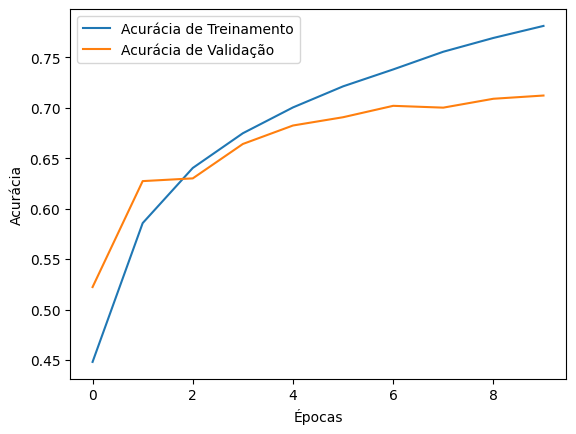

In [1]:
# Exemplo de CNN no Google Colab com CIFAR-10

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Carregar o dataset CIFAR-10
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalizar as imagens
train_images, test_images = train_images / 255.0, test_images / 255.0

# Definir a arquitetura da CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

# Compilar o modelo
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Treinar o modelo
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

# Avaliar o modelo
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'Acurácia no conjunto de teste: {test_acc}')

# Plotar a acurácia durante o treinamento
plt.plot(history.history['accuracy'], label='Acurácia de Treinamento')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.show()